In [2]:
import re
import torch
import random
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader
from datasets import Dataset as HFDataset
import torch.nn as nn
import torch.optim as optim
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize

In [4]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [5]:
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [6]:
data = pd.read_csv("/kaggle/input/lang-data/rus.txt", delimiter='\t', header=None)
data.rename(columns={0: 'en', 1: 'ru', 2: 'comment'}, inplace=True)
data = data[['en', 'ru']]
data['en'] = data['en'].apply(clean_text)
data['ru'] = data['ru'].apply(clean_text)

In [7]:
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

In [20]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", clean_up_tokenization_spaces=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [17]:
train_dataset = HFDataset.from_pandas(train_data)
val_dataset = HFDataset.from_pandas(val_data)
test_dataset = HFDataset.from_pandas(test_data)

In [8]:
def tokenize_function(examples):
    source = tokenizer(examples['ru'], padding="max_length", truncation=True, max_length=128)
    target = tokenizer(examples['en'], padding="max_length", truncation=True, max_length=128)
    source["labels"] = target["input_ids"]
    return source

In [19]:
train_dataset = train_dataset.map(tokenize_function, batched=False)
val_dataset = val_dataset.map(tokenize_function, batched=False)
test_dataset = test_dataset.map(tokenize_function, batched=False)

Map:   0%|          | 0/290708 [00:00<?, ? examples/s]

Map:   0%|          | 0/36339 [00:00<?, ? examples/s]

Map:   0%|          | 0/36339 [00:00<?, ? examples/s]

In [9]:
def custom_collate_fn(batch):
    input_ids = [torch.tensor(item['input_ids']) for item in batch]
    labels = [torch.tensor(item['labels']) for item in batch]
    
    input_ids = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=tokenizer.pad_token_id)
    
    return {
        'input_ids': input_ids,
        'labels': labels
    }

In [21]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=custom_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, collate_fn=custom_collate_fn)

In [10]:
class FeedForward(nn.Module):
    def __init__(self, embed_size, ff_hidden_size, dropout=0.1):
        super(FeedForward, self).__init__()
        self.fc1 = nn.Linear(embed_size, ff_hidden_size)
        self.fc2 = nn.Linear(ff_hidden_size, embed_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        return self.fc2(self.dropout(torch.relu(self.fc1(x))))

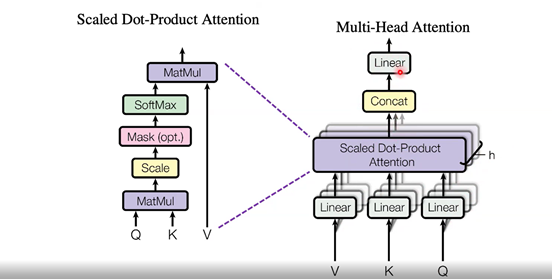
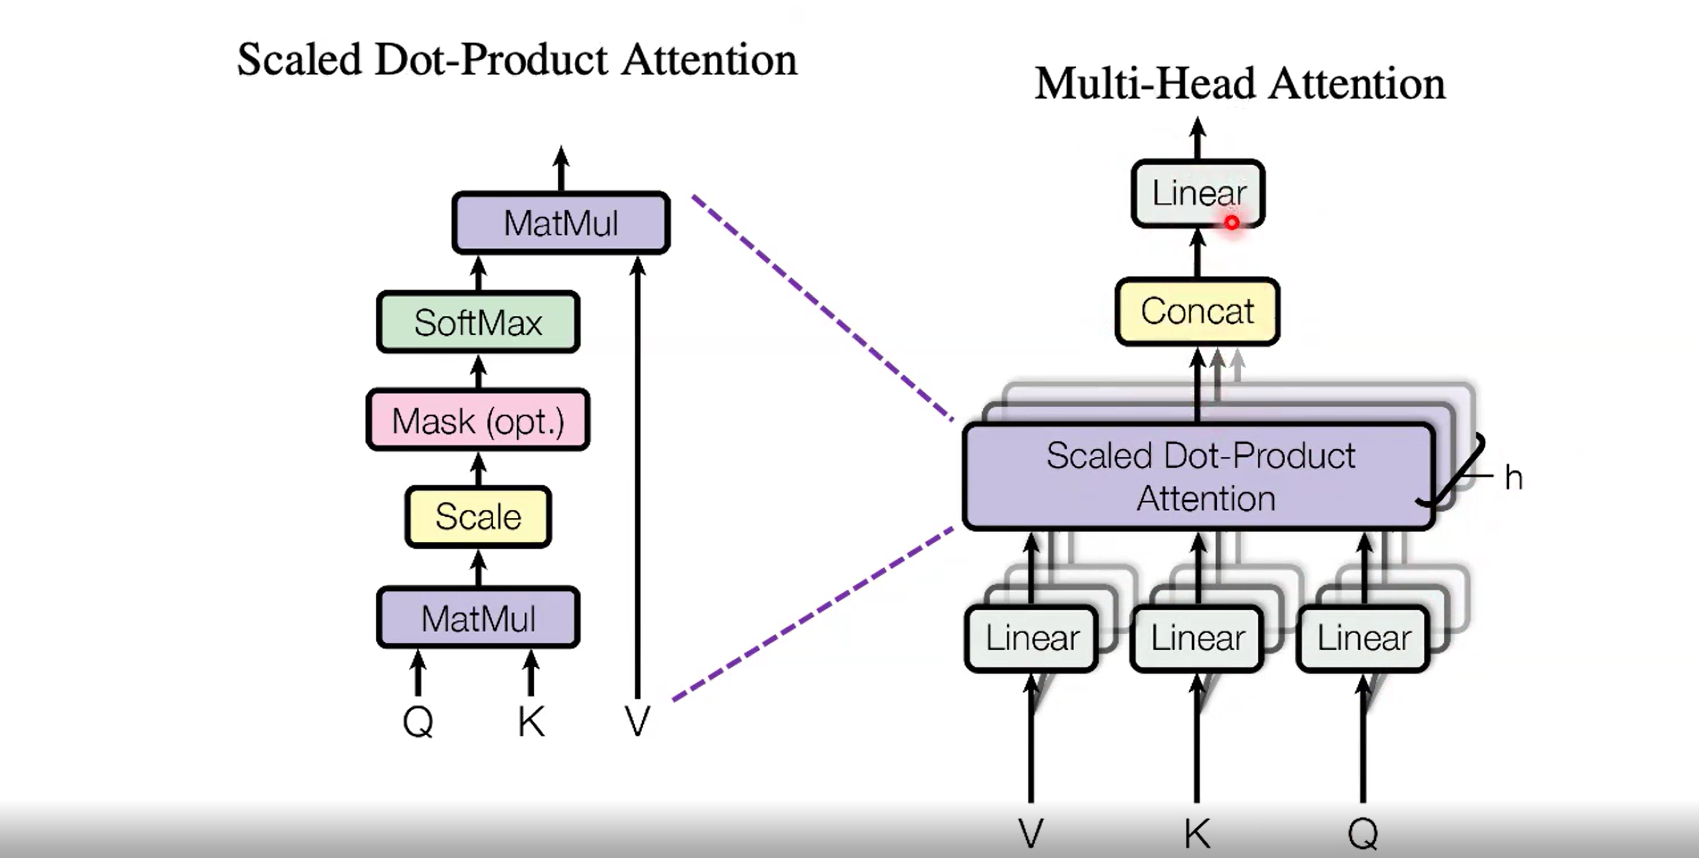
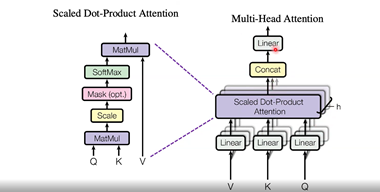

In [11]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        assert self.head_dim * heads == embed_size, "embed_size должно делиться на количество голов"

        self.q_linear = nn.Linear(embed_size, embed_size)
        self.k_linear = nn.Linear(embed_size, embed_size)
        self.v_linear = nn.Linear(embed_size, embed_size)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]

        q = self.q_linear(query)
        k = self.k_linear(key)
        v = self.v_linear(value)

        query_len = q.shape[1]
        key_len = k.shape[1]
        value_len = v.shape[1]

        q = q.view(batch_size, query_len, self.heads, self.head_dim).permute(0, 2, 1, 3)
        k = k.view(batch_size, key_len, self.heads, self.head_dim).permute(0, 2, 1, 3)
        v = v.view(batch_size, value_len, self.heads, self.head_dim).permute(0, 2, 1, 3)

        # Attention scores: [batch_size, heads, query_len, key_len]
        energy = torch.matmul(q, k.permute(0, 1, 3, 2)) / (self.head_dim ** 0.5)

        if mask is not None:
            if mask.dim() == 2:
                mask = mask.unsqueeze(1).unsqueeze(2)
            elif mask.dim() == 3:
                mask = mask.unsqueeze(1)
            energy = energy.masked_fill(mask == 0, float("-1e20"))

        attention = torch.softmax(energy, dim=-1)

        out = torch.matmul(attention, v)

        out = out.permute(0, 2, 1, 3).contiguous()
        out = out.view(batch_size, query_len, self.embed_size)

        return self.fc_out(out)

In [12]:
class EncoderLayer(nn.Module):
    def __init__(self, embed_size, heads, ff_hidden_size, dropout):
        super(EncoderLayer, self).__init__()
        self.attention = MultiHeadAttention(embed_size, heads)
        self.feed_forward = FeedForward(embed_size, ff_hidden_size, dropout)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask=None):
        attention = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attention))
        
        forward = self.feed_forward(x)
        x = self.norm2(x + self.dropout(forward))
        
        return x

In [13]:
class DecoderLayer(nn.Module):
    def __init__(self, embed_size, heads, ff_hidden_size, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attention = MultiHeadAttention(embed_size, heads)
        self.cross_attention = MultiHeadAttention(embed_size, heads)
        self.feed_forward = FeedForward(embed_size, ff_hidden_size, dropout)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.norm3 = nn.LayerNorm(embed_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        self_attention = self.self_attention(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(self_attention))
        
        cross_attention = self.cross_attention(x, encoder_output, encoder_output, src_mask)
        x = self.norm2(x + self.dropout(cross_attention))
        
        forward = self.feed_forward(x)
        x = self.norm3(x + self.dropout(forward))
        
        return x

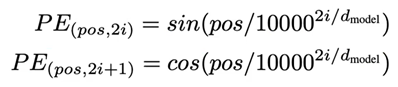

In [14]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_size, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, embed_size)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_size, 2).float() * (-torch.log(torch.tensor(10000.0)) / embed_size))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [15]:
class Encoder(nn.Module):
    def __init__(self, src_vocab_size, embed_size, num_layers, heads, ff_hidden_size, dropout, max_len=5000):
        super(Encoder, self).__init__()
        self.embed_size = embed_size
        self.word_embedding = nn.Embedding(src_vocab_size, embed_size)
        self.position_encoding = PositionalEncoding(embed_size, max_len)
        self.layers = nn.ModuleList([
            EncoderLayer(embed_size, heads, ff_hidden_size, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        # x: (batch_size, seq_len)
        x = self.word_embedding(x) * (self.embed_size ** 0.5)
        x = self.position_encoding(x)
        x = self.dropout(x)
        
        for layer in self.layers:
            x = layer(x, mask)
            
        return x

In [16]:
class Decoder(nn.Module):
    def __init__(self, tgt_vocab_size, embed_size, num_layers, heads, ff_hidden_size, dropout, max_len=5000):
        super(Decoder, self).__init__()
        self.embed_size = embed_size
        self.word_embedding = nn.Embedding(tgt_vocab_size, embed_size)
        self.position_encoding = PositionalEncoding(embed_size, max_len)
        self.layers = nn.ModuleList([
            DecoderLayer(embed_size, heads, ff_hidden_size, dropout)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(embed_size, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        # x: (batch_size, seq_len)
        x = self.word_embedding(x) * (self.embed_size ** 0.5)
        x = self.position_encoding(x)
        x = self.dropout(x)
        
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
            
        return self.fc_out(x)

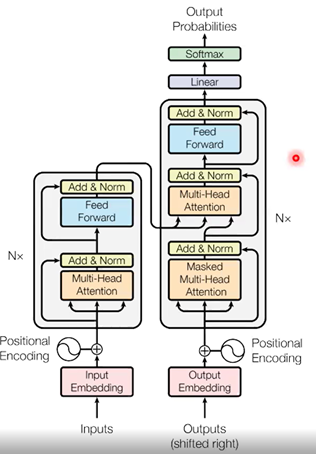
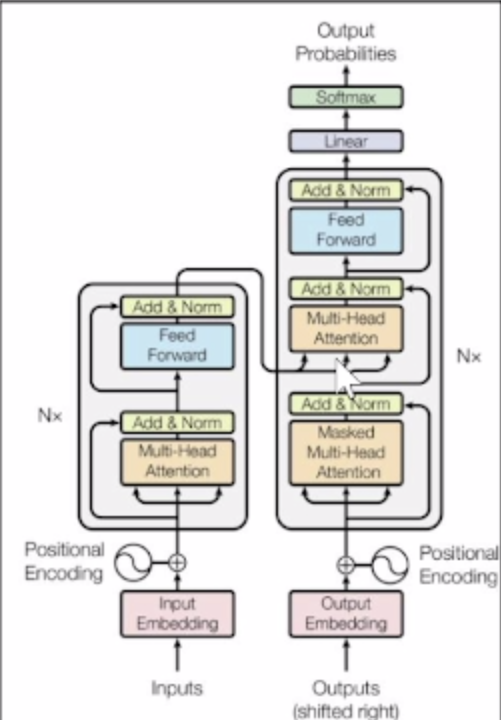

In [17]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, src_pad_idx, tgt_pad_idx,
                 embed_size=512, num_layers=6, heads=8, ff_hidden_size=2048, dropout=0.1):
        super(Transformer, self).__init__()
        
        self.encoder = Encoder(src_vocab_size, embed_size, num_layers, heads, ff_hidden_size, dropout)
        self.decoder = Decoder(tgt_vocab_size, embed_size, num_layers, heads, ff_hidden_size, dropout)
        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    def make_src_mask(self, src):
        # src: (batch_size, src_len)
        src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)
        return src_mask
    
    def make_tgt_mask(self, tgt):
        # tgt: (batch_size, tgt_len)
        batch_size, tgt_len = tgt.shape
        
        tgt_pad_mask = (tgt != self.tgt_pad_idx).unsqueeze(1).unsqueeze(2)
        
        tgt_sub_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=self.device)).bool()
        

        tgt_sub_mask = tgt_sub_mask.expand(batch_size, 1, tgt_len, tgt_len)
        
        tgt_mask = tgt_pad_mask & tgt_sub_mask
        return tgt_mask
    
    def forward(self, src, tgt):
        # src: (batch_size, src_len)
        # tgt: (batch_size, tgt_len)
        
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        
        enc_output = self.encoder(src, src_mask)
        dec_output = self.decoder(tgt, enc_output, src_mask, tgt_mask)
        
        return dec_output

In [21]:
input_dim = len(tokenizer)
output_dim = len(tokenizer)
embed_size = 256
heads = 8
num_layers = 4
ff_hidden_size = 1024
dropout = 0.1
src_pad_idx = tokenizer.pad_token_id
tgt_pad_idx = tokenizer.pad_token_id
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [22]:
model = Transformer(
    input_dim, output_dim, src_pad_idx, tgt_pad_idx,
    embed_size, num_layers, heads, ff_hidden_size, dropout
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

In [23]:
def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(iterator, desc="Evaluating"):
            src = batch['input_ids'].to(device)
            tgt = batch['labels'].to(device)
            
            output = model(src, tgt[:, :-1])
            
            output = output.contiguous().view(-1, output.shape[-1])
            tgt = tgt[:, 1:].contiguous().view(-1)
            
            loss = criterion(output, tgt)
            epoch_loss += loss.item()
    
    return epoch_loss / len(iterator)

In [24]:
def train(model, iterator, optimizer, criterion, clip=1):
    model.train()
    epoch_loss = 0
    
    for batch in tqdm(iterator, desc="Training"):
        if isinstance(batch['input_ids'], list):
            src = torch.tensor(batch['input_ids']).to(device)
            tgt = torch.tensor(batch['labels']).to(device)
        else:
            src = batch['input_ids'].to(device)
            tgt = batch['labels'].to(device)
            
        optimizer.zero_grad()
        
        output = model(src, tgt[:, :-1])
        
        output = output.contiguous().view(-1, output.shape[-1])
        tgt = tgt[:, 1:].contiguous().view(-1)
        
        loss = criterion(output, tgt)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        
        optimizer.step()
        epoch_loss += loss.item()
        
    return epoch_loss / len(iterator)

In [25]:
def translate_sentence(model, sentence, tokenizer, max_len=50):
    model.eval()
    if isinstance(sentence, str):
        sentence = clean_text(sentence)
        tokens = tokenizer(sentence, return_tensors="pt").input_ids.to(device)
    else:
        tokens = sentence
    
    target = torch.tensor([[tokenizer.cls_token_id]]).to(device)
    
    for _ in range(max_len):
        with torch.no_grad():
            output = model(tokens, target)
            pred_token = output.argmax(2)[:, -1].item()
            
            target = torch.cat(
                [target, torch.tensor([[pred_token]]).to(device)], dim=1
            )
            
            if pred_token == tokenizer.sep_token_id:
                break
    
    target_tokens = target.squeeze(0).tolist()
    return tokenizer.decode(target_tokens, skip_special_tokens=True)

In [35]:
def calculate_bleu(model, data_loader, tokenizer):
    references = []
    hypotheses = []
    
    for batch in tqdm(data_loader, desc="Calculating BLEU"):
        src = batch['input_ids'].to(device)
        tgt = batch['labels'].to(device)
        
        for i in range(src.shape[0]):
            src_sentence = src[i].unsqueeze(0)
            tgt_sentence = tokenizer.decode(tgt[i], skip_special_tokens=True).lower()
            
            pred_sentence = translate_sentence(model, src_sentence, tokenizer)
            pred_sentence = pred_sentence.lower()
            
            references.append([word_tokenize(tgt_sentence)])
            hypotheses.append(word_tokenize(pred_sentence))
    
    smoothing = SmoothingFunction().method1
    return corpus_bleu(references, hypotheses, smoothing_function=smoothing)

In [36]:
N_EPOCHS = 15
best_valid_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(N_EPOCHS):
    print(f"Starting epoch {epoch+1}/{N_EPOCHS}")
    train_loss = train(model, train_loader, optimizer, criterion)
    valid_loss = evaluate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(valid_loss)
    
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'transformer-ru-en.pt')
    
    print(f'Epoch: {epoch+1}')
    print(f'Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f}')

Starting epoch 1/15


Evaluating: 100%|██████████| 1136/1136 [00:53<00:00, 21.06it/s]


Epoch: 1
Train Loss: 3.1195 | Valid Loss: 2.2483
Starting epoch 2/15


Evaluating: 100%|██████████| 1136/1136 [00:53<00:00, 21.20it/s]


Epoch: 2
Train Loss: 2.0718 | Valid Loss: 1.8098
Starting epoch 3/15


...

Epoch: 13
Train Loss: 0.8399 | Valid Loss: 1.0392
Starting epoch 14/15


Evaluating: 100%|██████████| 1136/1136 [00:53<00:00, 21.32it/s]


Epoch: 14
Train Loss: 0.8035 | Valid Loss: 1.0262
Starting epoch 15/15


Evaluating: 100%|██████████| 1136/1136 [00:53<00:00, 21.26it/s]


Epoch: 15
Train Loss: 0.7713 | Valid Loss: 1.0090


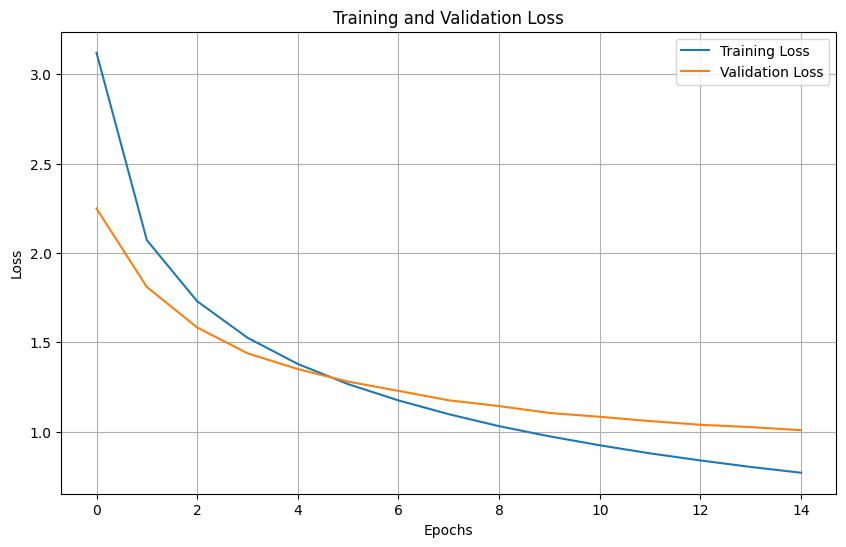

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
model_path = '/kaggle/input/transformer-based-ru-en-machine-translator/pytorch/default/1/transformer-ru-en.pt'

state_dict = torch.load(model_path, weights_only=True)

model.load_state_dict(state_dict)

model.eval()

Transformer(
  (encoder): Encoder(
    (word_embedding): Embedding(30522, 256)
    (position_encoding): PositionalEncoding()
    (layers): ModuleList(
      (0-3): 4 x EncoderLayer(
        (attention): MultiHeadAttention(
          (q_linear): Linear(in_features=256, out_features=256, bias=True)
          (k_linear): Linear(in_features=256, out_features=256, bias=True)
          (v_linear): Linear(in_features=256, out_features=256, bias=True)
          (fc_out): Linear(in_features=256, out_features=256, bias=True)
        )
        (feed_forward): FeedForward(
          (fc1): Linear(in_features=256, out_features=1024, bias=True)
          (fc2): Linear(in_features=1024, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (dropout): Dropout(p

In [38]:
bleu_score = calculate_bleu(model, test_loader, tokenizer)
print(f'Final BLEU Score: {bleu_score:.4f}')

/tmp/ipykernel_31/837906138.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('transformer-ru-en.pt'))
Calculating BLEU: 100%|██████████| 

Final BLEU Score: 0.4880


In [37]:
ru_sentence = "Привет, как дела?" # Hi, how are you doing?
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Том — домохозяин." # Tom is a househusband.
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Том, наверное, был болен." # Tom must've been sick.
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Я слышал, вы собираетесь выйти замуж." # I heard you are going to get married.
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "С чего ты взял, что Том вообще подумает пойти на свидание с Мэри?" # What makes you think Tom would ever consider going on a date with Mary?
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Люди, страдающие аутизмом, зачастую не смотрят в глаза собеседнику." # People with autism often don't make eye contact when talking to someone.
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "У Тома аллергия на некоторые продукты, так что ему приходится быть осторожным в еде." # Tom has some food allergies, so he has to be careful about what he eats.
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Его амнезия - проблема скорее психологическая, нежели физиологическая." # His loss of memory is a psychological problem rather than a physical one.
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Если бы вы услышали, как он говорит по-французски, вы бы приняли его за француза." # If you were to hear him speak French, you would take him for a Frenchman
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Пирог не получился хорошим, потому что у муки истёк срок годности." # The cake didn't turn out well because the flour was past its use-by date
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Я понимаю, как сильно ты хочешь пойти на вечеринку, но я не могу тебя отпустить." # I understand how much you want to go to the party, but I can't let you go.
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

Привет, как дела?: hello how are you doing

Том — домохозяин.: tom is a housewife

Том, наверное, был болен.: tom must ve been sick

Я слышал, вы собираетесь выйти замуж.: i heard you are going to get married

С чего ты взял, что Том вообще подумает пойти на свидание с Мэри?: what makes you think tom will ever go to the dance with mary

Люди, страдающие аутизмом, зачастую не смотрят в глаза собеседнику.: people with autism often study in self defense than to the united states

У Тома аллергия на некоторые продукты, так что ему приходится быть осторожным в еде.: tom didn t have any idea what was going on to happen to eat if it was necessary

Его амнезия - проблема скорее психологическая, нежели физиологическая.: his explanation is a great political political asylum

Если бы вы услышали, как он говорит по-французски, вы бы приняли его за француза.: if you had your french what would they speak french speak french

Пирог не получился хорошим, потому что у муки истёк срок годности.: it took

In [38]:
ru_sentence = "Привет, как дела?" #Hello, how are you?
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Оно живое" #It's alive
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Сколько ты обучал эту нейросеть?" #How long did you train this neural network?
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Как долго ты изучаешь нейросети?" #How long have you been studying neural networks?
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Зачем ты сюда пришел?" #Why did you come here?
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Что это у тебя? Камера. А я думала сова." #What do you have there? A camera. I thought it was an owl.
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "У меня была какая-то тактика и я ее предерживался." #I had some kind of tactics and I stuck to it.
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Повар спрашивает повара, какова твоя профессия?" # The cook asks the cook, what is your profession?
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Ты не пройдешь." #You shall not pass.
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

ru_sentence = "Вы кто такие я вас не звал." #Who are you? I didn't invite you.
translated_sentence = translate_sentence(model, ru_sentence, tokenizer)
print(f'{ru_sentence}: {translated_sentence}\n') 

Привет, как дела?: hello how are you doing

Оно живое: it s alive

Сколько ты обучал эту нейросеть?: how many weeks did you learn to do that

Как долго ты изучаешь нейросети?: how long do you study history

Зачем ты сюда пришел?: why did you come here

Что это у тебя? Камера. А я думала сова.: what s that s the matter i gave you

У меня была какая-то тактика и я ее предерживался.: i had some reason so angry i have my idea

Повар спрашивает повара, какова твоя профессия?: the couple had a procrastinate

Ты не пройдешь.: won t you come

Вы кто такие я вас не звал.: you re the way i called you

